In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Checking dataset and craete a DataFrame of it

In [2]:
from pathlib import Path
import random
from collections import Counter

data_path = Path("../../data/raw/diabetic_retinopathy/")
random_state = random.seed(42)

df = pd.DataFrame({
    "id_code" : [],
    "height" : [],
    "width" : [],
    "diagnosis" : [],
})

extensions = Counter()
channel_counts = Counter()

samples = list()
wrong_dim_files = list()
counter = 0
for folder in data_path.iterdir():
    if folder.is_dir():
        
        files = [f for f in folder.iterdir() if f.is_file()]

        # Fetch a random sample from each class
        if files is not None:
            random_file = random.choice(files)
            sample = {
                'file_path' : random_file,
                'file_name' : random_file.name
            }
            samples.append(sample)

        
        for file in iter(files):
            # Check format and suffix
            extensions[file.suffix.lower()] += 1
            
            img = cv2.imread(file)
            
            # Check color channel(s)
            if img.ndim == 2:
                channel_counts["Grayscale (1)"] += 1
                height, width = img.shape
            else:
                channel_counts[f"{img.shape[2]} channels"] += 1
                height, width, color_channels = img.shape
            
            # Check if heights and widths are right
            if height and width != 224:
                wrong_dim_files.append(file)
            else:
                # Set a new record in dataframe
                new_record = {
                "id_code" : file.stem,
                "height" : height,
                "width" : width,
                "diagnosis" : None,
                }
                df.loc[len(df)] = new_record
                
        print(f"{folder.name} : {len(files)} files detected.")
        counter += len(files)

# Set id_code as primary key
df.set_index("id_code", inplace=True)

print(f"\nOverally {counter} files.")

Mild : 370 files detected.
Moderate : 999 files detected.
No_DR : 1805 files detected.
Proliferate_DR : 295 files detected.
Severe : 193 files detected.

Overally 3662 files.


In [3]:
df.head()

,height,width,diagnosis
id_code,,,
0024cdab0c1e,224,224,None
00cb6555d108,224,224,None
0124dffecf29,224,224,None
01b3aed3ed4c,224,224,None
0369f3efe69b,224,224,None


### Check files that should their heights or widths get fixed

In [4]:
wrong_dim_files

[]

### Check the format

In [5]:
extensions

Counter({'.png': 3662})

### Check Color Channels

In [6]:
channel_counts

Counter({'3 channels': 3662})

### Merge DataFrame with Labels

In [7]:
labels_path = Path("../../data/raw/diabetic_retinopathy/train.csv")


labels = { 
        0 : "No_DR",
        1 : "Mild",
        2 : "Moderate",
        3 : "Severe",
        4 : "Proliferate_DR",
}
df_label = pd.read_csv(labels_path)
df_label.set_index("id_code", inplace=True)
df_label.head()

,diagnosis
id_code,
000c1434d8d7,2
001639a390f0,4
0024cdab0c1e,1
002c21358ce6,0
005b95c28852,0


In [8]:
df["diagnosis"] = df_label["diagnosis"]
df

,height,width,diagnosis
id_code,,,
0024cdab0c1e,224,224,1
00cb6555d108,224,224,1
0124dffecf29,224,224,1
01b3aed3ed4c,224,224,1
0369f3efe69b,224,224,1
...,...,...,...
f9156aeffc5e,224,224,3
fb61230b99dd,224,224,3
fcc6aa6755e6,224,224,3


In [9]:
df.loc["000c1434d8d7"]

height       224
width        224
diagnosis      2
Name: 000c1434d8d7, dtype: int64

# Show Samples

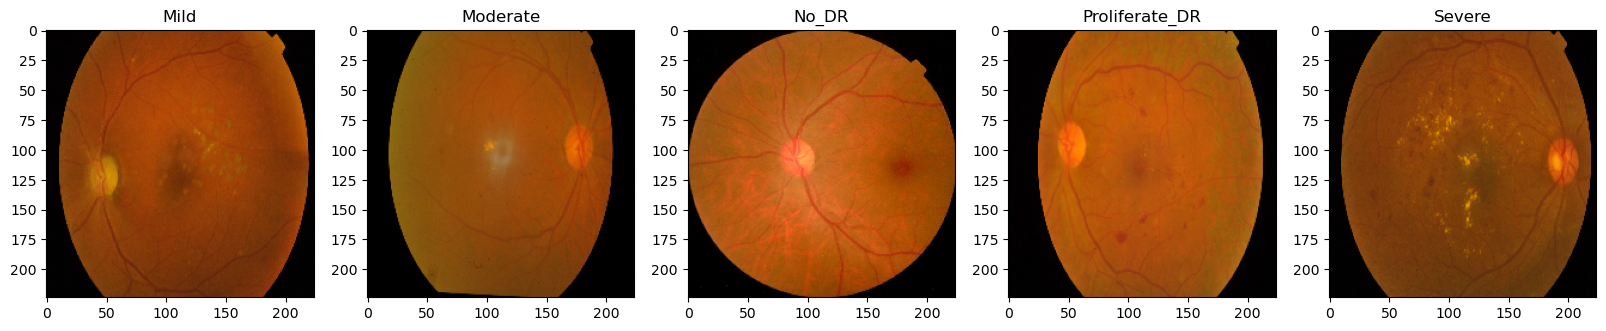

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, image in enumerate(samples):
    image_name = image["file_path"].stem
    image_label = df.loc[image_name, "diagnosis"]
    
    img = cv2.imread(str(image["file_path"]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img);
    axes[i].set_title(labels[image_label]);
    #axes[i].axis("off")
